Here is a project to detect "לשון הרע "

In [3]:
#%pip install pandas

Here we load the dataset
The dataset is available at https://www.kaggle.com/datasets/ferno2/training1600000processednoemoticoncsv

In [3]:
import pandas as pd

df = pd.read_csv('./training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1')
df.head()


,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


Here we will add columns names:

In [4]:
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df.head()

,sentiment,id,date,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


Why do we need 'query' column?

In [5]:
# Here we will check the different values in the 'query' column:
print(df['query'].unique())

['NO_QUERY']


It only has one value, so we can drop this column, 
but first we will copy the dateset:

In [6]:
data = df.copy()
data = data.drop(columns=['query'])
data.head()

,sentiment,id,date,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,joy_wolf,@Kwesidei not the whole crew


Same for the id column, we don't think it can help to tell if a given text is לשון הרע or not:

In [7]:
data = data.drop(columns=['id'])
data.head()

,sentiment,date,user,text
0,0,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,is upset that he can't update his Facebook by ...
1,0,Mon Apr 06 22:19:53 PDT 2009,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,my whole body feels itchy and like its on fire
3,0,Mon Apr 06 22:19:57 PDT 2009,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,Mon Apr 06 22:20:00 PDT 2009,joy_wolf,@Kwesidei not the whole crew


Here we will check the amount of rows of each type: 
0 - negative text
1 - positive text 

In [8]:
print(data['sentiment'].value_counts().loc[[0, 4]])

sentiment
0    799999
4    800000
Name: count, dtype: int64


In [9]:
print("Example with sentiment 0 - negative:")
print(data[data['sentiment'] == 0].iloc[0])

print("\nExample with sentiment 4 - positive:")
print(data[data['sentiment'] == 4].iloc[0])

Example with sentiment 0 - negative:
sentiment                                                    0
date                              Mon Apr 06 22:19:49 PDT 2009
user                                             scotthamilton
text         is upset that he can't update his Facebook by ...
Name: 0, dtype: object

Example with sentiment 4 - positive:
sentiment                                               4
date                         Mon Apr 06 22:22:45 PDT 2009
user                                                ersle
text         I LOVE @Health4UandPets u guys r the best!! 
Name: 799999, dtype: object


here we will check if any of the text lines are empty 

In [10]:
empty_text_rows = data[data['text'].str.strip() == '']
print(f"Number of rows with empty text: {len(empty_text_rows)}")

Number of rows with empty text: 0


We assume that rows labeled 0 that mentions someone else, are more likely to be לשון הרע  for example: 
* 0 - "@nationwideclass no, it's not behaving at all...."  - לשון הרע 
* 0 - "my whole body feels itchy and like its on fire" - לא לשון הרע 

So here we go and filter all rows that are negative sentiment (labeled 0) and contains '@'

In [11]:
neg_with_mentions = data[(data['sentiment'] == 0) & (data['text'].str.contains('@'))]
print("Number of negative tweets with mentions:", len(neg_with_mentions))

Number of negative tweets with mentions: 305210


About half from the data set with labeled 0

now we can get text like this: "@Kwesidei not the whole crew" - its negative but not לשון הרע 

So now we will find the text that are not only negative but also insulting or offensive.
We do that by creating a list a not good words that if where in a sentence and mention some one we will say the sentence will be לשון הרע

In [12]:
keywords = [
    'stupid', 
    'hate',
    'hates',
    'hate this',
    'hates that',
    'cry',
    'idiot',
    'idiots',
    'worst', 
    'annoying', 
    'ugly',
    'terrible',
    'awful',
    'horrible',
    'horrid',
    'dislike',
    'disgusting',
    'disgusted',
    'disappointed',
    'liar', 
    'bad', 
    'dumb',
    'fool',
    'foolish', 
    'not good',
    'not great',
    'not ok',   
    'not okay',
    'not nice',
    'not like',
    'not happy',
    'upset',
    'iam angry',
    'angry',
    ]

personal_references = ['@', 'he', 'she', 'you', 'your', 'his', 'her', 'them']


In [13]:
def is_weak_lashon(text):
    text = text.lower()
    return any(word in text for word in keywords)

data['lashon_hara_guess'] = data.apply(
    lambda row: int(row['sentiment'] == 0 and any(word in row['text'] for word in personal_references) and is_weak_lashon(row['text'])),
    axis=1
)

Lets see the dataset now: 

In [14]:
data.head()

,sentiment,date,user,text,lashon_hara_guess
0,0,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,is upset that he can't update his Facebook by ...,1
1,0,Mon Apr 06 22:19:53 PDT 2009,mattycus,@Kenichan I dived many times for the ball. Man...,0
2,0,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,my whole body feels itchy and like its on fire,0
3,0,Mon Apr 06 22:19:57 PDT 2009,Karoli,"@nationwideclass no, it's not behaving at all....",0
4,0,Mon Apr 06 22:20:00 PDT 2009,joy_wolf,@Kwesidei not the whole crew,0


Lets make sure that the data set are balanced:

In [15]:
data['lashon_hara_guess'].value_counts()
# 1 = likely Lashon Hara, 0 = unlikely

lashon_hara_guess
0    1544726
1      55273
Name: count, dtype: int64

Here we have more rows with labels 0. 
To have the same amount of data for 0 and for 1

In [16]:
# Separate the two classes
class_0 = data[data['lashon_hara_guess'] == 0]
class_1 = data[data['lashon_hara_guess'] == 1]

# Downsample the majority class
min_count = min(len(class_0), len(class_1))
class_0_balanced = class_0.sample(n=min_count, random_state=42)
class_1_balanced = class_1.sample(n=min_count, random_state=42)

# Combine and shuffle
balanced_data = pd.concat([class_0_balanced, class_1_balanced]).sample(frac=1, random_state=42).reset_index(drop=True)
print(balanced_data['lashon_hara_guess'].value_counts())

lashon_hara_guess
1    55273
0    55273
Name: count, dtype: int64


In [26]:
print("Example with sentiment 1 - likely:")
balanced_data[balanced_data['lashon_hara_guess'] == 1].sample()[['text']]['text'].values[0]


Example with sentiment 1 - likely:


"@iAM_AshleyMarie  aw il b there tonight briefly then out to MIGENTE Stef's bday ... gonna b stupid!"

In [28]:
print("Example with sentiment 0 - unlikely:")
balanced_data[balanced_data['lashon_hara_guess'] == 0].sample()[['text']]['text'].values[0]

Example with sentiment 0 - unlikely:


'Wow what a sunny day,  just recovering some erased files '

So were going to try a few methods: 
- ML
- Deep learning 
- Transformers 

then compare the results:

--  Machine Learning -- 
We used a logistic Regression classifier with sigmoid function

Why It's Good:
- Fast to train
- Interpretable (you can inspect weights)
- Surprisingly effective for text tasks

This will automatically choose the best regularization strength by doing internal cross-validation and selecting the best model based on validation scores — helping to prevent overfitting.

In [19]:
# %pip install scikit-learn

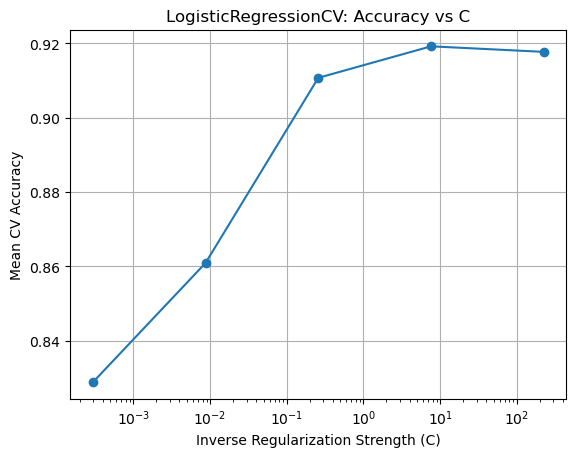

                 precision    recall  f1-score   support

Not Lashon Hara       0.88      0.96      0.92     11055
    Lashon Hara       0.95      0.88      0.91     11055

       accuracy                           0.92     22110
      macro avg       0.92      0.92      0.92     22110
   weighted avg       0.92      0.92      0.92     22110



In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report

# 1. Prepare Data
X = balanced_data['text']
y = balanced_data['lashon_hara_guess']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Vectorize
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. Train with LogisticRegressionCV
Cs = np.logspace(-3, 2, 5, 10, 15)  # Try different regularization values
logreg_cv = LogisticRegressionCV(Cs=Cs, cv=5, scoring='accuracy', max_iter=1000)
logreg_cv.fit(X_train_vec, y_train)

# 5. Plot accuracy vs C
mean_scores = logreg_cv.scores_[1].mean(axis=0)  # scores_ is a dict keyed by class label

plt.semilogx(logreg_cv.Cs_, mean_scores, marker='o')
plt.xlabel("Inverse Regularization Strength (C)")
plt.ylabel("Mean CV Accuracy")
plt.title("LogisticRegressionCV: Accuracy vs C")
plt.grid(True)
plt.show()

# 6. Final evaluation
y_pred = logreg_cv.predict(X_test_vec)
print(classification_report(y_test, y_pred, target_names=["Not Lashon Hara", "Lashon Hara"]))


Accuracy: 92%
Time: 9s


In [44]:
n_params = logreg_cv.coef_.size + logreg_cv.intercept_.size
print(f"Number of parameters: {n_params}")

Number of parameters: 5001


In [47]:
def predict_lashon_hara_logreg(text):
    vec = vectorizer.transform([text])
    pred = logreg_cv.predict(vec)[0]
    return "Lashon Hara" if pred == 1 else "Not Lashon Hara"

print("@john you're such an idiot")
print(predict_lashon_hara_logreg("@john you're such an idiot"))
print()
print("@john you're such an good person")
print(predict_lashon_hara_logreg("@john you're such a good person"))
print()
print("@john you're such a not a good person")
print(predict_lashon_hara_logreg("@john you're such a not good person"))
print('?')


@john you're such an idiot
Lashon Hara

@john you're such an good person
Not Lashon Hara

@john you're such a not a good person
Not Lashon Hara
?


-- Deep learning --


Recurrent Neural Network (RNN) – Text classifier using Keras (TensorFlow) with an embedding layer, LSTM, and Dense layers
It's more powerful than models like logistic regression or simple feedforward networks 
because it can learn temporal dependencies, like:
Text:
“@david wow you're just the smartest guy in the room 🙄”

LSTM will think:
It captures the sarcasm from context and emoji.
Logistic regression: 
might be fooled by the word "smartest".

In [23]:
# %pip install tensorflow


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# 1. Prepare Data
X = balanced_data['text'].values
y = balanced_data['lashon_hara_guess'].values

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Tokenize & Pad
vocab_size = 10000
maxlen = 30

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

# 4. Model
rnn_lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

rnn_lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',    # You can also monitor 'val_accuracy'
    patience=2,            # Stop after 2 epochs of no improvement
    restore_best_weights=True  # Restore weights from the best epoch
)

# Train with early stopping
rnn_lstm_history = rnn_lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=10,               # Can be higher since early stopping will stop earlier if needed
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]  
)

# 6. Evaluate
loss, acc = rnn_lstm_model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {acc:.4f}")




Epoch 1/10


c:\Users\shmue\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1244/1244 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.8626 - loss: 0.3024 - val_accuracy: 0.9732 - val_loss: 0.1255
Epoch 2/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9708 - loss: 0.1271 - val_accuracy: 0.9739 - val_loss: 0.1143
Epoch 3/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.9720 - loss: 0.1117 - val_accuracy: 0.9720 - val_loss: 0.1186
Epoch 4/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.9751 - loss: 0.0944 - val_accuracy: 0.9692 - val_loss: 0.1375
691/691 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9711 - loss: 0.1226
Test Accuracy: 0.9700


Accuracy: 97% 
time: 4m 10s

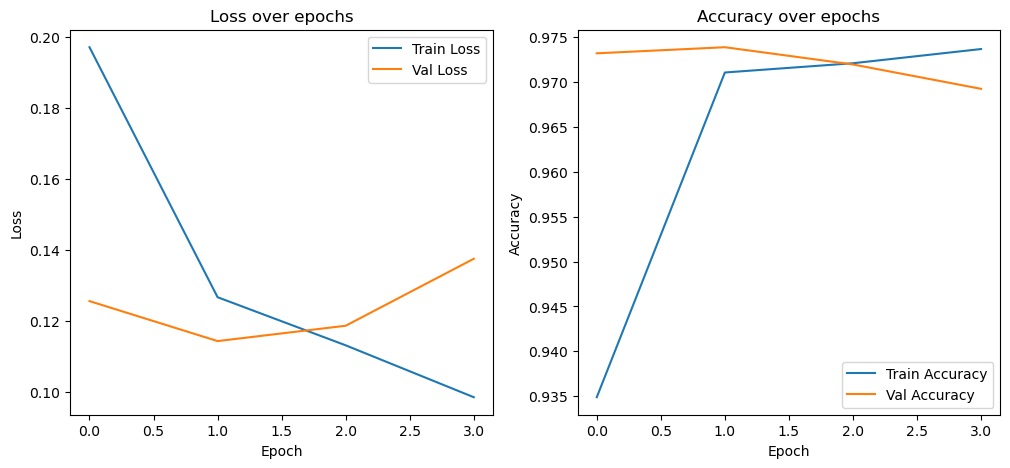

In [50]:
# Plot loss and accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(rnn_lstm_history.history['loss'], label='Train Loss')
plt.plot(rnn_lstm_history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(rnn_lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(rnn_lstm_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [52]:
rnn_lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 30, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,994,565 (15.24 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,663,044 (10.16 MB)

In [54]:
def predict_lashon_hara_rnn(text):
    # Tokenize and pad the input text
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    # Predict
    prob = rnn_lstm_model.predict(pad)[0][0]
    return "Lashon Hara" if prob >= 0.5 else "Not Lashon Hara"


In [99]:
print("@john you're such an idiot")
print(predict_lashon_hara_rnn("@john you're such an idiot"))
print()
print("@john you're such an good person")
print(predict_lashon_hara_rnn("@john you're such a good person"))
print()
print("@john you're such a not good person")
print(predict_lashon_hara_rnn("@john you're such a not good person"))
print("?")

@john you're such an idiot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
Lashon Hara

@john you're such an good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Not Lashon Hara

@john you're such a not good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Not Lashon Hara
?


Here we will try to fix this: 
- to increase the Increase Sequence Length
- try Pretrained GloVe Embeddings

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# 1. Prepare Data
X = balanced_data['text'].values
y = balanced_data['lashon_hara_guess'].values

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Tokenize & Pad
vocab_size = 10000
maxlen = 50  # Increased maxlen to 50 for better context handling

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

# 4. Model
rnn_lstm_model_50 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

rnn_lstm_model_50.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',    # You can also monitor 'val_accuracy'
    patience=2,            # Stop after 2 epochs of no improvement
    restore_best_weights=True  # Restore weights from the best epoch
)

# Train with early stopping
rnn_lstm_history_50 = rnn_lstm_model_50.fit(
    X_train_pad,
    y_train,
    epochs=10,               # Can be higher since early stopping will stop earlier if needed
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]  
)

# 6. Evaluate
loss, acc = rnn_lstm_model_50.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {acc:.4f}")




Epoch 1/10


c:\Users\shmue\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1244/1244 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.6947 - loss: 0.4860 - val_accuracy: 0.9733 - val_loss: 0.1230
Epoch 2/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.9701 - loss: 0.1368 - val_accuracy: 0.9743 - val_loss: 0.1154
Epoch 3/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.9715 - loss: 0.1190 - val_accuracy: 0.9737 - val_loss: 0.1151
Epoch 4/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.9731 - loss: 0.1049 - val_accuracy: 0.9724 - val_loss: 0.1264
Epoch 5/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.9747 - loss: 0.0854 - val_accuracy: 0.9737 - val_loss: 0.1321
691/691 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9705 - loss: 0.1280
Test Accuracy: 0.9692


In [88]:
def predict_lashon_hara_rnn_50(text):
    # Tokenize and pad the input text
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    # Predict
    prob = rnn_lstm_model_50.predict(pad)[0][0]
    return "Lashon Hara" if prob >= 0.5 else "Not Lashon Hara"

In [100]:
print("@john you're such an idiot")
print(predict_lashon_hara_rnn_50("@john you're such an idiot"))
print()
print("@john you're such an good person")
print(predict_lashon_hara_rnn_50("@john you're such a good person"))
print()
print("@john you're such a not good person")
print(predict_lashon_hara_rnn_50("@john you're such a not good person"))

@john you're such an idiot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Lashon Hara

@john you're such an good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Not Lashon Hara

@john you're such a not good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Lashon Hara


In [119]:
rnn_lstm_model_50.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,994,565 (15.24 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,663,044 (10.16 MB)

Pretrained GloVe Embeddings

load GloVe Embeddings

In [90]:
embedding_index = {}
with open("./pre_trained/glove.6B.100d.txt", encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector
print(f"Found {len(embedding_index)} word vectors.")

Found 400000 word vectors.


Create the Embedding Matrix:

In [ ]:
embedding_dim = 100

embedding_matrix = np.zeros((vocab_size, embedding_dim))
word_index = tokenizer.word_index

for word, i in word_index.items():
    if i < vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Embedding

# 1. Prepare Data
X = balanced_data['text'].values
y = balanced_data['lashon_hara_guess'].values

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Tokenize & Pad
vocab_size = 10000
maxlen = 50  # Increased maxlen to 50 for better context handling

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=maxlen,
    trainable=False  # Optional: prevent updating GloVe vectors during training
)

# 4. Model
rnn_lstm_model_pretrained = Sequential([
    embedding_layer,
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

rnn_lstm_model_pretrained.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',    # You can also monitor 'val_accuracy'
    patience=2,            # Stop after 2 epochs of no improvement
    restore_best_weights=True  # Restore weights from the best epoch
)

# Train with early stopping
rnn_lstm_history_pretrained = rnn_lstm_model_pretrained.fit(
    X_train_pad,
    y_train,
    epochs=20,               # Can be higher since early stopping will stop earlier if needed
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop] 
)

# 6. Evaluate
loss, acc = rnn_lstm_model_pretrained.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {acc:.4f}")


Epoch 1/20


c:\Users\shmue\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1244/1244 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.8136 - loss: 0.4045 - val_accuracy: 0.9357 - val_loss: 0.1991
Epoch 2/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.9368 - loss: 0.2076 - val_accuracy: 0.9594 - val_loss: 0.1578
Epoch 3/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.9438 - loss: 0.1972 - val_accuracy: 0.9608 - val_loss: 0.1461
Epoch 4/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9555 - loss: 0.1680 - val_accuracy: 0.9665 - val_loss: 0.1357
Epoch 5/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9593 - loss: 0.1592 - val_accuracy: 0.9681 - val_loss: 0.1337
Epoch 6/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.9631 - loss: 0.1488 - val_accuracy: 0.9685 - val_loss: 0.1286
Epoch 7/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.9640 - loss: 0.1455 - val_accuracy: 0.9670 - val_loss: 0.1349
Epoch 8/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.9626 - loss: 0.14

In [94]:
def predict_lashon_hara_rnn_pre(text):
    # Tokenize and pad the input text
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    # Predict
    prob = rnn_lstm_model_50.predict(pad)[0][0]
    return "Lashon Hara" if prob >= 0.5 else "Not Lashon Hara"

In [96]:
print("@john you're such an idiot")
print(predict_lashon_hara_rnn_pre("@john you're such an idiot"))
print()
print("@john you're such an good person")
print(predict_lashon_hara_rnn_pre("@john you're such a good person"))
print()
print("@john you're such a not good person")
print(predict_lashon_hara_rnn_pre("@john you're such a not good person"))

@john you're such an idiot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Lashon Hara

@john you're such an good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Not Lashon Hara

@john you're such a not good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Lashon Hara


In [120]:
rnn_lstm_model_pretrained.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,133,061 (4.32 MB)

 Trainable params: 44,353 (173.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

 Optimizer params: 88,708 (346.52 KB)

-- Bidirectional LSTM (BiLSTM) for Text Classification ---
Model Type:
- A Recurrent Neural Network (RNN) using LSTM cells
- Bidirectional = it reads the sequence left-to-right and right-to-left
- Great for capturing long-range and contextual meaning

| Feature                          | Value                        |
| -------------------------------- | ---------------------------  |
| Learns word order?               | ✅ Yes                      |
| Captures context from both ends? | ✅✅ Yes (bidirectional)    |
| Handles long sentences?          | ✅ Yes                      |
| Training time?                   | 🟡 Medium (slower than CNN) |


In [56]:
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

BiLSTM_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

BiLSTM_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

BiLSTM_history = BiLSTM_model.fit(
    X_train_pad,
    y_train,
    epochs=10,  # can be large, early stopping will halt early
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, acc = BiLSTM_model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {acc:.4f}")

Epoch 1/10


c:\Users\shmue\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1244/1244 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.8734 - loss: 0.2901 - val_accuracy: 0.9741 - val_loss: 0.1118
Epoch 2/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9701 - loss: 0.1246 - val_accuracy: 0.9722 - val_loss: 0.1154
Epoch 3/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.9733 - loss: 0.0998 - val_accuracy: 0.9737 - val_loss: 0.1178
691/691 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9691 - loss: 0.1265
Test Accuracy: 0.9689


Accuracy: 96%
time: 2m 14s

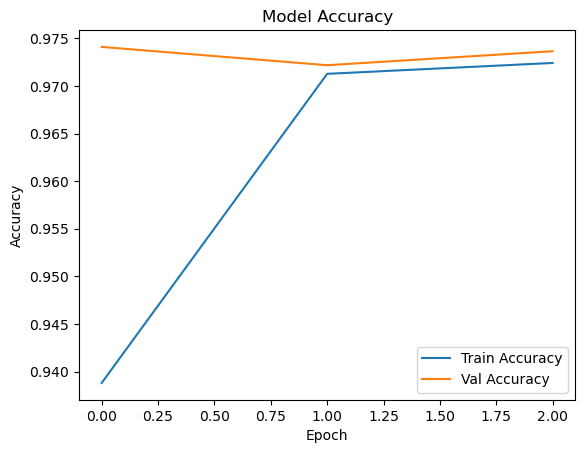

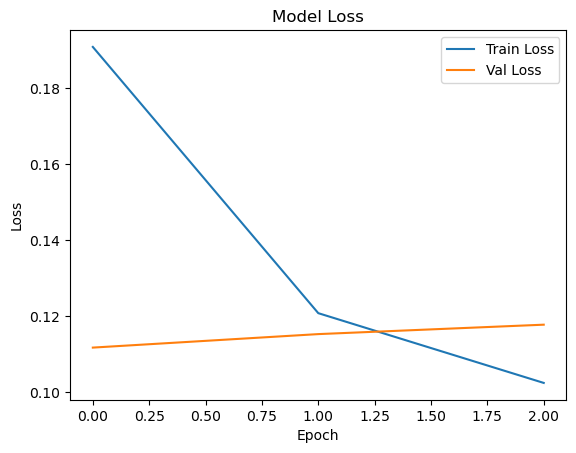

In [57]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(BiLSTM_history.history['accuracy'], label='Train Accuracy')
plt.plot(BiLSTM_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(BiLSTM_history.history['loss'], label='Train Loss')
plt.plot(BiLSTM_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [58]:
BiLSTM_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 30, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,148,933 (15.83 MB)

 Trainable params: 1,382,977 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,765,956 (10.55 MB)

In [102]:
def predict_lashon_hara_BiLSTM(text, tokenizer, model, maxlen=30):
    # Step 1: Tokenize
    seq = tokenizer.texts_to_sequences([text])
    
    # Step 2: Pad
    padded = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    
    # Step 3: Predict
    prob = model.predict(padded)[0][0]
    
    # Step 4: Interpret
    label = 1 if prob >= 0.5 else 0
    label_text = "Lashon Hara" if label == 1 else "Not Lashon Hara"
    
    return label_text, prob


predict

In [104]:
text = "@john you're such an idiot"
print(text)
label, confidence = predict_lashon_hara_BiLSTM(text, tokenizer, BiLSTM_model)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")
print()
text = "@john you're such a good person"
print(text)
label, confidence = predict_lashon_hara_BiLSTM(text, tokenizer, BiLSTM_model)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")
print()

text = "@john you're such a not good person"
print(text)
label, confidence = predict_lashon_hara_BiLSTM(text, tokenizer, BiLSTM_model)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")

@john you're such an idiot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Prediction: Lashon Hara (Confidence: 0.9178)

@john you're such a good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Prediction: Not Lashon Hara (Confidence: 0.0030)

@john you're such a not good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prediction: Lashon Hara (Confidence: 0.7042)


We get better results then the classic ML 

-- DM modal: Embedding + Global Average Pooling + Dense (MLP) -- 

GlobalAveragePooling1D - Averages all word embeddings into a single vector
Suppose you have a sentence of 5 words, and each word is represented by a 4-dimensional embedding:


In [ ]:
[
 [0.1, 0.2, 0.3, 0.4],  ← word 1
 [0.5, 0.1, 0.0, 0.3],  ← word 2
 [0.2, 0.3, 0.5, 0.2],  ← word 3
 [0.0, 0.1, 0.2, 0.1],  ← word 4
 [0.1, 0.2, 0.2, 0.3]   ← word 5
]

In [ ]:
GlobalAveragePooling1D takes the average across all rows, like this:

mean of each column = [
 (0.1+0.5+0.2+0.0+0.1)/5 = 0.18,
 (0.2+0.1+0.3+0.1+0.2)/5 = 0.18,
 (0.3+0.0+0.5+0.2+0.2)/5 = 0.24,
 (0.4+0.3+0.2+0.1+0.3)/5 = 0.26
]
So now your sentence becomes just one vector of 4 numbers, not 5 vectors of 4:
→ [0.18, 0.18, 0.24, 0.26]

advantages: 
- Much faster than LSTM
- Captures general topic/word presence but not word order
- Good for short, simple sentences or when you don’t need context modeling

| Feature              | This Model         | LSTM                         |
| -------------------- | ------------------ | ---------------------------  |
| Captures word order? | ❌ No              | ✅ Yes                      |
| Training speed       | ⚡ Fast            | 🐢 Slower                   |
| Accuracy potential   | 😐 Medium          | 🔥 Higher (on complex data) |
| Complexity           | 🟢 Simple          | 🔴 More complex             |


In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# 1. Prepare Data
X = balanced_data['text'].values
y = balanced_data['lashon_hara_guess'].values

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Tokenize & Pad
vocab_size = 10000
maxlen = 30

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

# 4. Model

Average_Pooling_modal = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    GlobalAveragePooling1D(),  # turns 2D sequences into flat vector
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])


Average_Pooling_modal.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train
apm_history = Average_Pooling_modal.fit(
    X_train_pad,
    y_train,
    epochs=10,  # Use a higher number, early stopping will cut it short
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
# 6. Evaluate
loss, acc = Average_Pooling_modal.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {acc:.4f}")

Epoch 1/10


c:\Users\shmue\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1244/1244 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8441 - loss: 0.3403 - val_accuracy: 0.9497 - val_loss: 0.1667
Epoch 2/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9574 - loss: 0.1480 - val_accuracy: 0.9536 - val_loss: 0.1559
Epoch 3/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9630 - loss: 0.1233 - val_accuracy: 0.9464 - val_loss: 0.1725
Epoch 4/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9678 - loss: 0.1061 - val_accuracy: 0.9533 - val_loss: 0.1667
691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9520 - loss: 0.1621
Test Accuracy: 0.9504


Accuracy: 95%
and the speed is 1m 50s

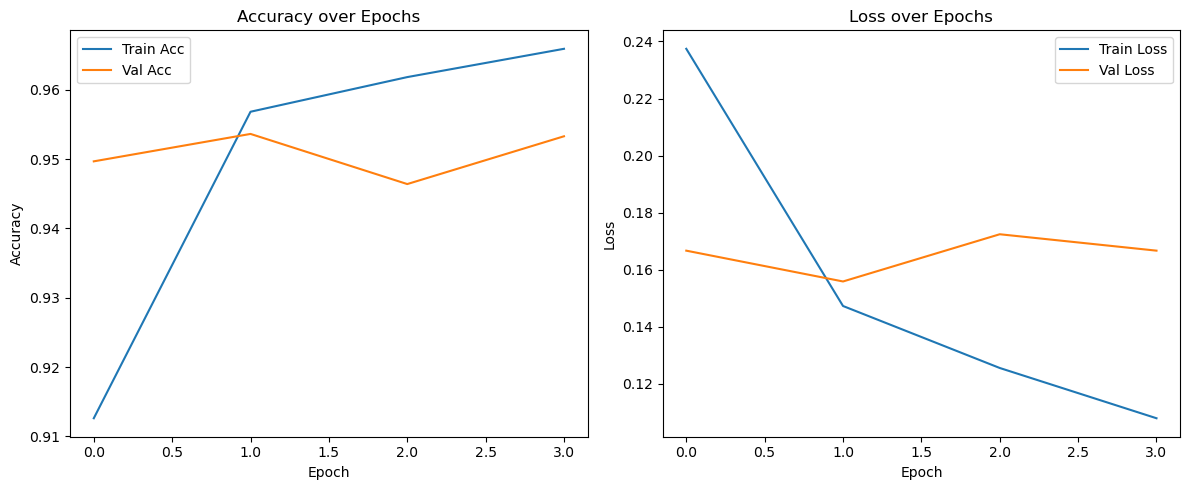

In [79]:
# Plot accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(apm_history.history['accuracy'], label='Train Acc')
plt.plot(apm_history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(apm_history.history['loss'], label='Train Loss')
plt.plot(apm_history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [105]:
def predict_lashon_hara_apm(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    prob = Average_Pooling_modal.predict(padded)[0][0]
    label = "Lashon Hara" if prob >= 0.5 else "Not Lashon Hara"
    return label, prob


In [107]:
text = "@john you're such an idiot"
print(text)
label, confidence = predict_lashon_hara_apm(text)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")
print()
text = "@john you're such a good person"
print(text)
label, confidence = predict_lashon_hara_apm(text)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")
print()
text = "@john you're such a not good person"
print(text)
label, confidence = predict_lashon_hara_apm(text)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")
print("?")

@john you're such an idiot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction: Not Lashon Hara (Confidence: 0.1383)

@john you're such a good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Prediction: Not Lashon Hara (Confidence: 0.0110)

@john you're such a not good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: Not Lashon Hara (Confidence: 0.0555)
?


In [82]:
Average_Pooling_modal.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 30, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,914,501 (14.93 MB)

 Trainable params: 1,304,833 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,609,668 (9.96 MB)

-- DL: Multilayer Perceptron (MLP) for Text Classification --
Model Type:
A fully connected feedforward neural network
No awareness of word order or sequence, just uses numerical input vectors

Uses TfidfVectorizer - Converts text into a flat vector of word/token importance (no word order)

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


# 1. Prepare Data
X = balanced_data['text'].values
y = balanced_data['lashon_hara_guess'].values

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# 4. MLP Model
MLP_modal = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_vec.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

MLP_modal.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train
MLP_history = MLP_modal.fit(
    X_train_vec,
    y_train,
    epochs=20,  # longer, early stopping will prevent overfitting
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


# 6. Evaluate
loss, acc = MLP_modal.evaluate(X_test_vec, y_test)
print(f"Test Accuracy: {acc:.4f}")


c:\Users\shmue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.8446 - loss: 0.3528 - val_accuracy: 0.9545 - val_loss: 0.1587
Epoch 2/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9591 - loss: 0.1502 - val_accuracy: 0.9608 - val_loss: 0.1450
Epoch 3/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9670 - loss: 0.1126 - val_accuracy: 0.9607 - val_loss: 0.1534
Epoch 4/20
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9726 - loss: 0.0844 - val_accuracy: 0.9579 - val_loss: 0.1689
691/691 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9543 - loss: 0.1653
Test Accuracy: 0.9540


Accuracy: 95%
and time is: 2m 7s

In [66]:
MLP_modal.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,951,493 (7.44 MB)

 Trainable params: 650,497 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,300,996 (4.96 MB)

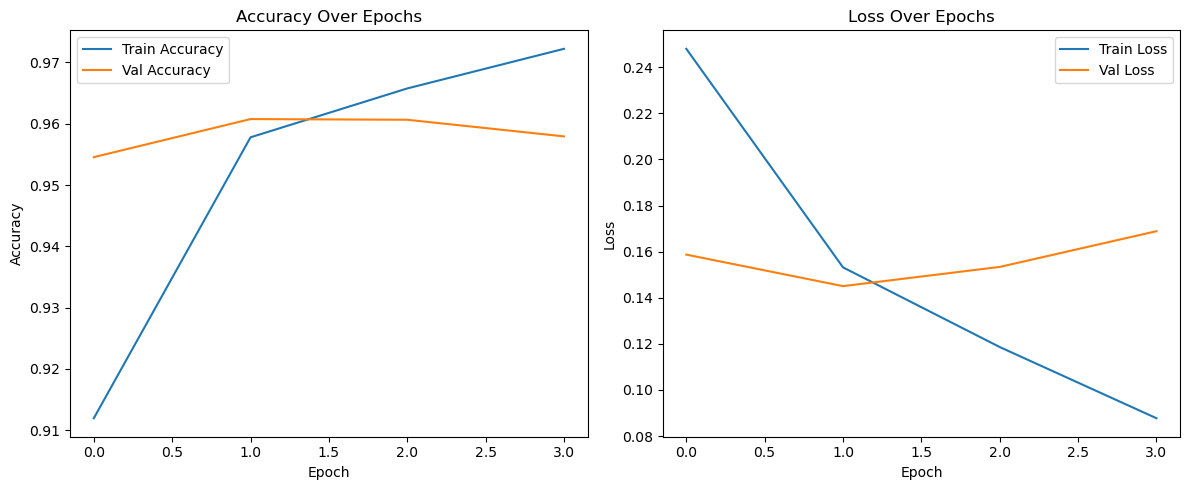

In [67]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(MLP_history.history['accuracy'], label='Train Accuracy')
plt.plot(MLP_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(MLP_history.history['loss'], label='Train Loss')
plt.plot(MLP_history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [109]:
def predict_lashon_hara_mpl(text):
    # Step 1: Vectorize the input text
    vec = vectorizer.transform([text]).toarray()
    
    # Step 2: Predict probability
    prob = MLP_modal.predict(vec)[0][0]
    
    # Step 3: Interpret result
    label = "Lashon Hara" if prob >= 0.5 else "Not Lashon Hara"
    
    return label, prob


In [110]:
text = "@john you're such an idiot"
print(text)
label, confidence = predict_lashon_hara_mpl(text)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")
print()
text = "@john you're such a good person"
print(text)
label, confidence = predict_lashon_hara_mpl(text)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")
print()
text = "@john you're such a not good person"
print(text)
label, confidence = predict_lashon_hara_mpl(text)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")

@john you're such an idiot
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step
Prediction: Lashon Hara (Confidence: 0.9601)

@john you're such a good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: Not Lashon Hara (Confidence: 0.0334)

@john you're such a not good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: Lashon Hara (Confidence: 0.6719)


Here we see it manages to catch

-- DL: CNN --

A 1D CNN designed to detect local patterns in sequences of word embeddings for text classification

Summary Table

| Feature                   | CNN for Text  |
| ------------------------- | ------------  |
| Learns word order?        | ✅ (local)    |
| Good for sarcasm/context? | ❌ Limited    |
| Great for phrase patterns | ✅ Yes        |
| Requires padding & tokens | ✅ Yes        |
| Training speed            | ⚡ Fast       |



In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

Cnn_modal = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    Conv1D(128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

Cnn_modal.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train with early stopping and save history
cnn_history = Cnn_modal.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
             
loss, acc = Cnn_modal.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {acc:.4f}")

c:\Users\shmue\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8982 - loss: 0.2568 - val_accuracy: 0.9750 - val_loss: 0.1110
Epoch 2/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9718 - loss: 0.1088 - val_accuracy: 0.9735 - val_loss: 0.1147
Epoch 3/10
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9794 - loss: 0.0637 - val_accuracy: 0.9674 - val_loss: 0.1514
691/691 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9705 - loss: 0.1230
Test Accuracy: 0.9701


Accuracy: 97%
time: 1m 20s

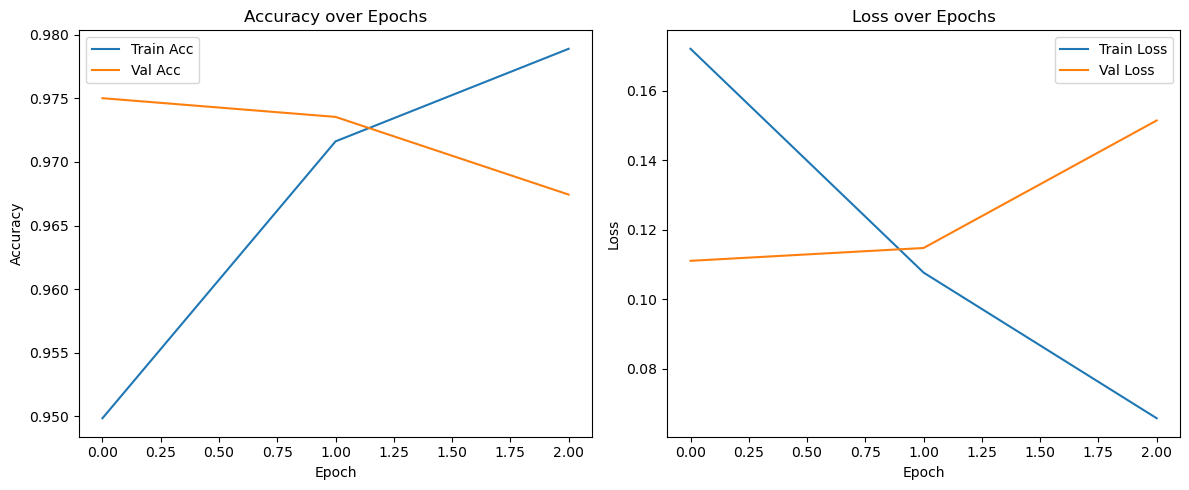

In [73]:
import matplotlib.pyplot as plt

# Plot accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [1]:
def predict_lashon_hara_cnn(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    prob = Cnn_modal.predict(padded)[0][0]
    label = "Lashon Hara" if prob >= 0.5 else "Not Lashon Hara"
    return label, prob


In [ ]:

text = "@john you're such an idiot"
print(text)
label, confidence = predict_lashon_hara_cnn(text)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")
print()
text = "@john you're such a good person"
print(text)
label, confidence = predict_lashon_hara_cnn(text)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")
print()
text = "@john you're such a not good person"
print(text)
label, confidence = predict_lashon_hara_cnn(text)
print(f"Prediction: {label} (Confidence: {confidence:.4f})")

@john you're such an idiot
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Lashon Hara (Confidence: 0.9591)

@john you're such a good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Prediction: Not Lashon Hara (Confidence: 0.0022)

@john you're such a not good person
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Prediction: Lashon Hara (Confidence: 0.9084)
?


In [77]:
Cnn_modal.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 30, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 26, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,117,253 (15.71 MB)

 Trainable params: 1,372,417 (5.24 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,744,836 (10.47 MB)

-- Transformers --

Uses self-attention to look at all words at once and model their relationships directly

to conclude: 

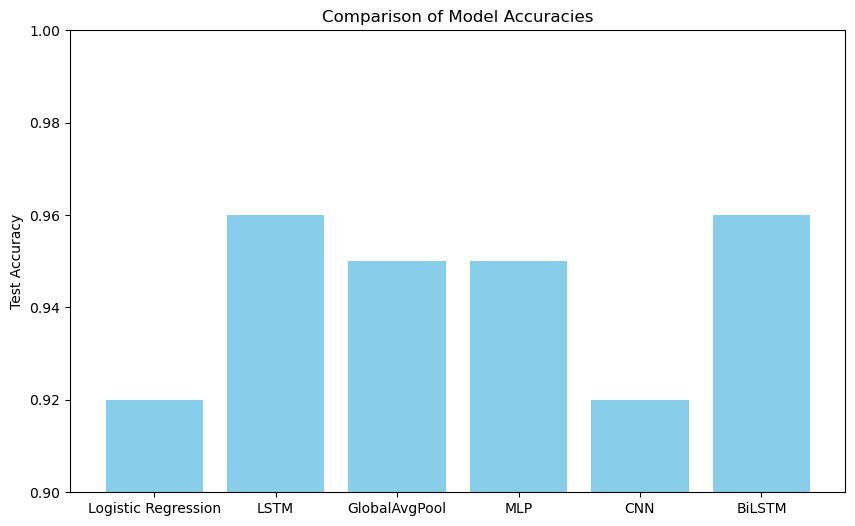

In [ ]:
import matplotlib.pyplot as plt

model_names = [
    "Logistic Regression", 
    "LSTM", 
    "GlobalAvgPool", 
    "MLP", 
    "CNN", 
    "BiLSTM",
]
accuracies = [
    0.92,  # Logistic Regression
    0.96,  # LSTM
    0.95,  # GlobalAvgPool
    0.95,  # MLP
    0.92,  # CNN
    0.96,  # BiLSTM

]

plt.figure(figsize=(10,6))
plt.bar(model_names, accuracies, color='skyblue')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Model Accuracies')
plt.ylim(0.9, 1.0)
plt.show()

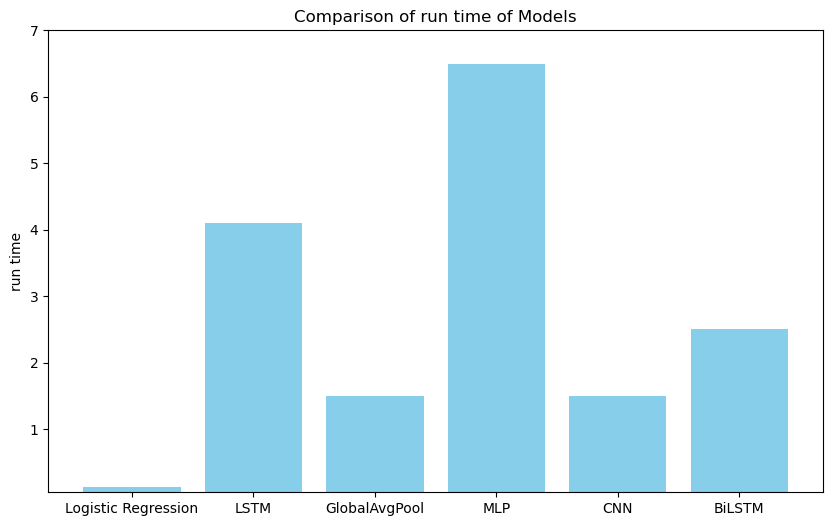

In [53]:
import matplotlib.pyplot as plt

model_names = [
    "Logistic Regression", 
    "LSTM", 
    "GlobalAvgPool", 
    "MLP", 
    "CNN", 
    "BiLSTM",
]
times = [
    0.13,  # Logistic Regression
    4.10,  # LSTM
    1.5,  # GlobalAvgPool
    6.5,  # MLP
    1.5,  # CNN
    2.5,  # BiLSTM
]

plt.figure(figsize=(10,6))
plt.bar(model_names, times, color='skyblue')
plt.ylabel('run time')
plt.title('Comparison of run time of Models')
plt.ylim(0.05, 7.0)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

model_names = [
    "Logistic Regression", 
    "LSTM", 
    "GlobalAvgPool", 
    "MLP", 
    "CNN", 
    "BiLSTM",
]
size = [
    5001,  # Logistic Regression
    3,994,565,  # LSTM
    3,914,501,  # GlobalAvgPool
    1,945,349,  # MLP
    4,111,109,  # CNN
    2.5,  # BiLSTM
]

plt.figure(figsize=(10,6))
plt.bar(model_names, size, color='skyblue')
plt.ylabel('run time')
plt.title('Comparison of run time of Models')
plt.ylim(0.05, 7.0)
plt.show()

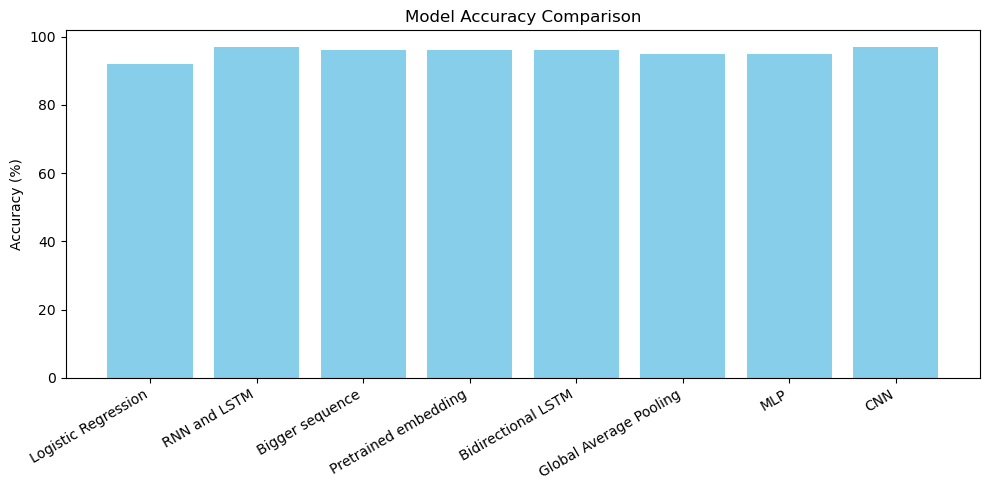

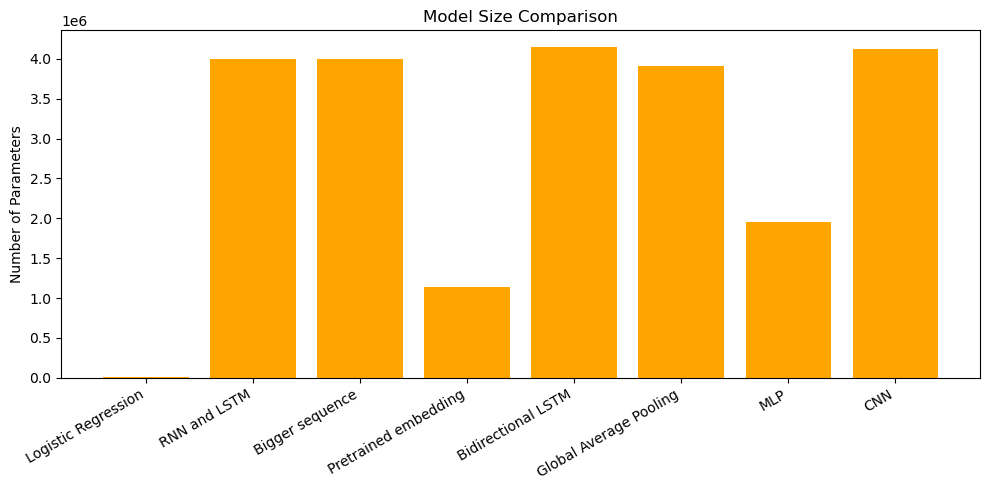

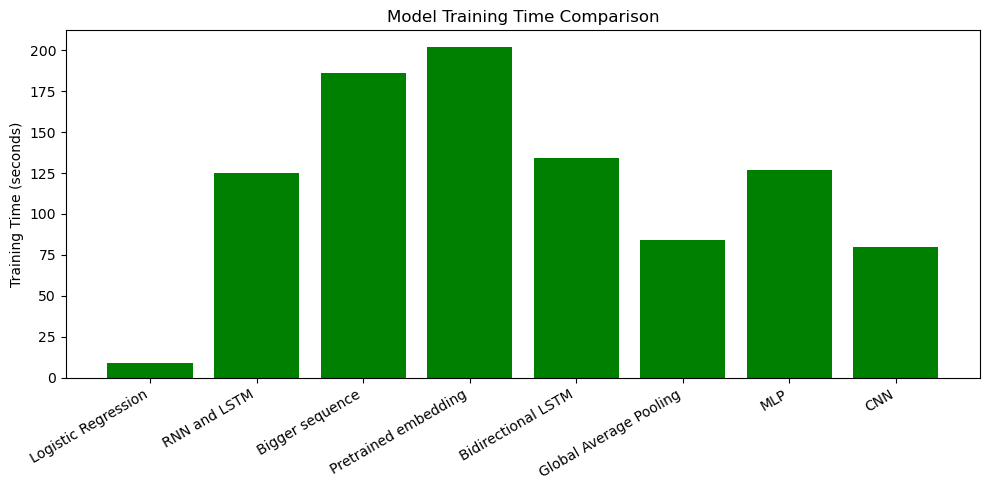

In [48]:
import pandas as pd

import matplotlib.pyplot as plt

# Create the data as a DataFrame
model_data = pd.DataFrame({
    "Model": [
        "Logistic Regression", "RNN and LSTM", "Bigger sequence", "Pretrained embedding",
        "Bidirectional LSTM", "Global Average Pooling", "MLP", "CNN"
    ],
    "Accuracy": [92, 97, 96, 96, 96, 95, 95, 97],
    "Size": [5001, 3994565, 3994565, 1133061, 4148933, 3914501, 1951493, 4117253],
    "Time (s)": [9, 125, 186, 202, 134, 84, 127, 80],
    "Past test": ["no", "no", "yes", "yes", "yes", "no", "yes", "yes"]
})

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.bar(model_data["Model"], model_data["Accuracy"], color='skyblue')
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Plot Size
plt.figure(figsize=(10, 5))
plt.bar(model_data["Model"], model_data["Size"], color='orange')
plt.ylabel("Number of Parameters")
plt.title("Model Size Comparison")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Plot Time
plt.figure(figsize=(10, 5))
plt.bar(model_data["Model"], model_data["Time (s)"], color='green')
plt.ylabel("Training Time (seconds)")
plt.title("Model Training Time Comparison")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

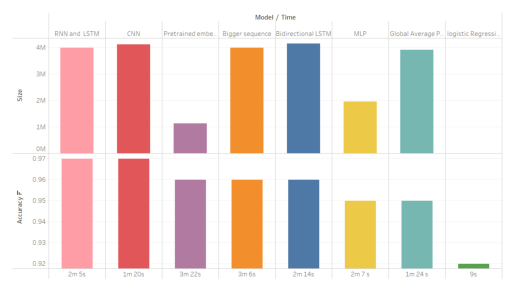

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('./table.png')  # replace with your image path
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

For conclusions and further research please see the power point in this folder